In [1]:
from pathlib import Path

import torch
import torch.nn.functional as F
from torch import nn

from torch.utils.data import DataLoader, random_split

from tts.jenny_dataset import JennyDataset
# from tts.model import PhonemeToSpectrogram, build_vocab
from tts.model_gaussian import PhonemeToSpectrogram, build_vocab

from tts.tokenizer import phonemize  # your function: str -> list[str]

from tqdm import tqdm

In [2]:
def get_device():
    if torch.cuda.is_available():   return torch.device("cuda")
    if torch.backends.mps.is_available(): return torch.device("mps")
    return torch.device("cpu")

## Create model

In [3]:
# ── Device ────────────────────────────────────────────────────────────────────

device = get_device()
print(f"device: {device}")

# ── Model ─────────────────────────────────────────────────────────────────────

vocab = build_vocab()

# model = PhonemeToSpectrogram(
#     vocab_size   = len(vocab),
#     d_model      = 64,#128,#256,
#     nhead        = 4,
#     num_layers   = 3,#3,#4,
#     n_mels       = 100,   # Vocos uses 100
#     patch_frames = 32,#32,#48,

# ).to(device)

# # Initialise with better weights for the time bit (equally spaced time bins)
# nn.init.zeros_(model.dur_head.net[-1].weight)
# nn.init.constant_(model.dur_head.net[-1].bias, 16.0) # seperate tokens by 16*256/24000 to start with ~ 0.2s



model = PhonemeToSpectrogram(
    vocab_size    = len(vocab),
    d_model       = 64,#128,         
    nhead         = 4,
    num_layers    = 2,
    n_mels        = 100,
    patch_frames  = 16,          # 16 closer to real phoneme length
    sigma_init    = 8.0,         # ~half patch width, ~1 average phoneme
    silence_init  = 8.0,         # matches your observed silence value
    sigma_weight  = 0.01,        # small nudge toward sharpness
).to(device)

# Duration: bias toward average phoneme length in frames
nn.init.zeros_(model.dur_head.net[-1].weight)
nn.init.constant_(model.dur_head.net[-1].bias, 16.0)  # tune to your actual frame rate




optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

print(f"params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")



device: mps
params: 413,443


## load data

In [4]:
# ── Data ──────────────────────────────────────────────────────────────────────
data_fpath = '/Users/dominicbates/Documents/Github/SimpleTTS/data/jenny'
full_ds = JennyDataset(data_fpath, max_frames = 800, max_tokens=120)
val_n   = int(len(full_ds) * 0.05)
trn_ds, val_ds = random_split(
    full_ds, [len(full_ds) - val_n, val_n],
    generator=torch.Generator().manual_seed(42),
)

def collate_fn(batch):
    mels, texts = zip(*batch)
    mels  = [m.squeeze(0) for m in mels]           # (n_mels, T) each
    max_t = max(m.shape[-1] for m in mels)
    padded = torch.stack([F.pad(m, (0, max_t - m.shape[-1])) for m in mels])
    return padded, list(texts)                      # (B, n_mels, T_max), list[str]

trn_loader = DataLoader(trn_ds, batch_size=8, shuffle=True,  collate_fn=collate_fn, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, collate_fn=collate_fn, num_workers=0)

print(f"train={len(trn_ds)}  val={len(val_ds)}")


[JennyDataset] 18304/20978 samples kept (max_frames=800, max_tokens=120) in /Users/dominicbates/Documents/Github/SimpleTTS/data/jenny/samples
train=17389  val=915


## Validate length of tokens and output mel

In [5]:
from tts.tokenizer import phonemize

token_counts = []
mel_lengths  = []

for mel, text in tqdm(full_ds):
    tokens = phonemize(text)
    token_counts.append(len(tokens))
    mel_lengths.append(mel.shape[-1])

100%|█████████████████████████████████████████████| 18304/18304 [00:02<00:00, 6573.13it/s]


(array([1157., 2490., 3364., 2445., 2763., 2123., 1470.,  981.,  905.,
         606.]),
 array([ 30. , 106.8, 183.6, 260.4, 337.2, 414. , 490.8, 567.6, 644.4,
        721.2, 798. ]),
 <BarContainer object of 10 artists>)

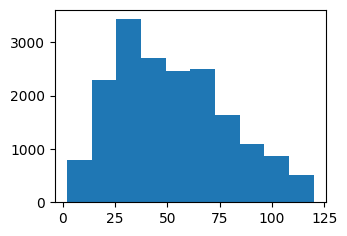

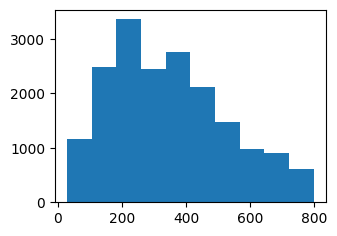

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(3.5,2.5))
plt.hist(token_counts)
plt.figure(figsize=(3.5,2.5))
plt.hist(mel_lengths)

## Set up training

In [7]:
# ── Text → token ids ──────────────────────────────────────────────────────────

def texts_to_ids(texts):
    all_ids = []
    for text in texts:
        tokens = phonemize(text)
        all_ids.append([vocab.get(t, vocab["<UNK>"]) for t in tokens])

    max_len   = max(len(ids) for ids in all_ids)
    pad_idx   = vocab["<PAD>"]
    id_tensor = torch.full((len(all_ids), max_len), pad_idx, dtype=torch.long, device=device)
    for i, ids in enumerate(all_ids):
        id_tensor[i, :len(ids)] = torch.tensor(ids, dtype=torch.long)

    padding_mask = (id_tensor == pad_idx)           # True = ignore
    return id_tensor, padding_mask

# ── Train / val step ──────────────────────────────────────────────────────────

def train_step(mels, texts):
    model.train()
    mels = mels.to(device)
    token_ids, padding_mask = texts_to_ids(texts)
    loss = model.compute_loss(token_ids, mels, padding_mask=padding_mask)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    return loss.item()

@torch.no_grad()
def val_step(mels, texts):
    model.eval()
    mels = mels.to(device)
    token_ids, padding_mask = texts_to_ids(texts)
    return model.compute_loss(token_ids, mels, padding_mask=padding_mask).item()




In [8]:
EVAL_TEXTS = [
    "Hello",
    "The quick brown fox jumps over the lazy dog.",
    "Oh my god! That is amazing!",
    "LOL haha that's mental dude!",
    "Can I ask you a question?",
    "Let's try a really long string to see what happens. And maybe a second sentence too?",
    "I like pizza, dogs, beer, and making long lists",
    "The dog said \"woof woof!\"",
    "\"La la la la la la\" she sang"
    # "",
]
 
 
def save_eval_specs(epoch):
    """Synthesise each eval text and save to RUN_DIR/specs/epoch_NNN_N.pt"""
    spec_dir = RUN_DIR / "specs"
    spec_dir.mkdir(parents=True, exist_ok=True)
    model.eval()
    with torch.no_grad():
        for i, text in enumerate(EVAL_TEXTS):
            token_ids, padding_mask = texts_to_ids([text])
            spec = model.synthesise(token_ids, padding_mask=padding_mask)  # (n_mels, T)
            torch.save(
                {"spec": spec.cpu(), "text": text, "epoch": epoch},
                spec_dir / f"epoch_{epoch:03d}_{i:02d}.pt",
            )
    print(f"  [eval] specs saved to {spec_dir}")
    model.train()


def print_debug(model, epoch):
    
    model.eval()
    with torch.no_grad():
        token_ids, padding_mask = texts_to_ids(["Hello!"])
        patches, positions = model(token_ids, padding_mask=padding_mask)
        print(f'\nEpoch {epoch} debugging...')
        print('- Silence:',model.silence.cpu().numpy())
        print('- Sigma:',model.sigma.cpu().numpy())
        print('- Positions for "Hello!":',positions[0].cpu().numpy())
    model.train()
        
 
     
def load_eval_spec(epoch, sample_idx=0):
    """
    Load a saved eval spectrogram back as a float32 tensor.
 
    Returns:
        spec: (n_mels, T)  float32  — ready to pass straight to the vocoder
        text: str
    """
    path = RUN_DIR / "specs" / f"epoch_{epoch:03d}_{sample_idx:02d}.pt"
    data = torch.load(path, weights_only=True)
    return data["spec"].float(), data["text"]


def print_mps_mem():
    alloc = torch.mps.current_allocated_memory() / 1024**3
    driver = torch.mps.driver_allocated_memory() / 1024**3
    rec = torch.mps.recommended_max_memory() / 1024**3

    print(
        f"Tensor={alloc:.2f} GB | "
        f"Driver={driver:.2f} GB | "
        f"Recommended Max={rec:.2f} GB"
    )

## Train

In [9]:

RUN_DIR = Path("./runs/run_gaussian_003")   # change for each experiment


EPOCHS  = 30
SAVE_EVERY = 2

(RUN_DIR / "checkpoints").mkdir(parents=True, exist_ok=True)

for epoch in range(1, EPOCHS + 1):

    # trn_losses = []
    # for m, t in tqdm(trn_loader, desc=f"epoch {epoch:03d} train", leave=False):
    #     trn_losses.append(train_step(m, t))

    #     # Hardcode save every 100 incase it fails
    #     if (epoch % 100) == 0:
    #         save_eval_specs(epoch)

    # val_losses = []
    # for m, t in tqdm(val_loader, desc=f"epoch {epoch:03d} val  ", leave=False):
    #     val_losses.append(val_step(m, t))


    trn_losses = []
    trn_iter = tqdm(trn_loader, desc=f"epoch {epoch:03d} train", leave=False)
    for i, (m, t) in enumerate(trn_iter):
        # if i >= 20:
        # trn_iter.close()  # explicitly release the iterator
            # break
        trn_losses.append(train_step(m, t))
        if (i % 10) == 0:
            print_mps_mem()
    trn_iter.close()
        
    val_losses = []
    val_iter = tqdm(val_loader, desc=f"epoch {epoch:03d} val", leave=False)
    for i, (m, t) in enumerate(val_iter):
        # if i >= 2:
        # val_iter.close()  # explicitly release the iterator
            # break
        val_losses.append(val_step(m, t))
    val_iter.close()

        
    # trn_losses = []
    # for i, (m, t) in enumerate(tqdm(trn_loader, desc=f"epoch {epoch:03d} train", leave=False)):
    #     if i >= 20: break
    #     trn_losses.append(train_step(m, t))

    # val_losses = []
    # for i, (m, t) in enumerate(tqdm(val_loader, desc=f"epoch {epoch:03d} val  ", leave=False)):
    #     if i >= 1: break
    #     val_losses.append(val_step(m, t))

    trn_loss = sum(trn_losses) / len(trn_losses)
    val_loss = sum(val_losses) / len(val_losses)
    print(f"epoch {epoch:03d}  train={trn_loss:.4f}  val={val_loss:.4f}")


    # Evals and saving
    print_debug(model, epoch)
    save_eval_specs(epoch)
    if epoch % SAVE_EVERY == 0:
        torch.save(
            {"epoch": epoch, "model": model.state_dict(),
             "optimizer": optimizer.state_dict(), "val_loss": val_loss},
            RUN_DIR / "checkpoints" / f"epoch_{epoch:03d}.pt",
        )


    # end of epoch cleaning of cache
    if device.type == "mps":
        torch.mps.empty_cache()
        

epoch 001 train:   0%|                                 | 1/2174 [00:01<1:09:38,  1.92s/it]

Tensor=0.02 GB | Driver=1.76 GB | Recommended Max=5.33 GB


epoch 001 train:   1%|▏                                 | 11/2174 [00:14<43:39,  1.21s/it]

Tensor=0.01 GB | Driver=3.82 GB | Recommended Max=5.33 GB


epoch 001 train:   1%|▎                                 | 21/2174 [00:28<49:45,  1.39s/it]

...

epoch 007 train:  53%|████████████████▉               | 1151/2174 [28:45<24:39,  1.45s/it]

Tensor=0.01 GB | Driver=8.17 GB | Recommended Max=5.33 GB


epoch 007 train:  53%|█████████████████               | 1161/2174 [28:59<21:40,  1.28s/it]

Tensor=0.01 GB | Driver=8.17 GB | Recommended Max=5.33 GB


KeyboardInterrupt: 

In [9]:
print_debug(model, epoch)


Epoch 1 debugging...
- Silence: nan
- Sigma: nan
- Positions for "Hello!": [nan nan nan nan nan nan]


In [9]:
lengths = []

for mels, texts in trn_loader:
    lengths.extend(mels.shape[2] for _ in range(mels.shape[0]))

print("count:", len(lengths))
print("max:", max(lengths))
print("min:", min(lengths))
print("mean:", sum(lengths)/len(lengths))

lengths_sorted = sorted(lengths)
print("95th percentile:", lengths_sorted[int(len(lengths)*0.95)])
print("99th percentile:", lengths_sorted[int(len(lengths)*0.99)])

count: 19930
max: 3876
min: 303
mean: 926.2412443552433
95th percentile: 1374
99th percentile: 1932


In [10]:
lengths = []

for batch in trn_loader:
    input_ids = batch["input_ids"]  # shape: (batch_size, seq_len)

    # Count non-padding tokens
    seq_lengths = (input_ids != tokenizer.pad_token_id).sum(dim=1)

    lengths.extend(seq_lengths.cpu().tolist())

print(f"Num sequences: {len(lengths)}")
print(f"Min length: {min(lengths)}")
print(f"Max length: {max(lengths)}")
print(f"Mean length: {sum(lengths)/len(lengths):.1f}")

TypeError: tuple indices must be integers or slices, not str

In [ ]:
save_eval_specs(epoch)

In [46]:
# for text in EVAL_TEXTS:
#     tokens = phonemize(text)
#     print(repr(text), "→", tokens)
# After a forward pass, inspect what positions look like


def checks(model, epoch):
    
    model.eval()
    with torch.no_grad():
        token_ids, padding_mask = texts_to_ids(["Hello!"])
        patches, positions = model(token_ids, padding_mask=padding_mask)
        print(f'\nEpoch {epoch} debugging...')
        print('- Silence:',model.silence.cpu().numpy())
        print('- Sigma:',model.sigma.cpu().numpy())
        print('- Positions for "Hello!":',positions[0].cpu().numpy())
    model.train()
        

In [47]:
checks(model, epoch)


Epoch 1 debugging...
- Silence: 7.997208
- Sigma: 7.998034
- Positions for "Hello!": [ 8.000727 24.002033 40.00332  56.004333 72.005104 88.00572 ]


In [23]:
print(positions[0].cpu().numpy())

[  8.000749  24.002129  40.00351   56.00469   72.00549   88.00671
 104.008575 120.00997  136.0107   152.01222  168.01366  184.01454
 200.01567  216.01653  232.01765  248.01912  264.0207   280.02206
 296.0228  ]


In [18]:
len(['HH',
 'AH0',
 'L',
 'OW1',
 '|',
 'DH',
 'EH1',
 'R',
 '|',
 '<PERIOD>',
 'HH',
 'AW1',
 'Z',
 '|',
 'IH1',
 'T',
 '|',
 'G',
 'OW1',
 'IH0',
 'NG',
 '|',
 '<QUESTION>'])

23

In [20]:
I would expect this to be around: ~4 seconds
We have 23 of my tokens there (using my tokenizer to phonemes



SyntaxError: invalid syntax (3981927091.py, line 1)

In [21]:
import torch.nn.functional as F
F.softplus(torch.tensor(2.8))  # should print ~16

tensor(2.8590)

In [ ]:
This prints 2.8590